# Statistik Ambulanz, Mediteams, Straßenambulanz & Pflegezimmer (2024–2026)

Dieses Notebook beantwortet:
1. **Wie entwickeln sich die einzelnen Bereiche?** (Zunahme / Abnahme, fairer Vergleich gleicher Zeiträume)
2. **Gibt es einen statistisch belastbaren Trend?** (Regression + Mann-Kendall-Test)
3. **Saisonalität** – welche Monate sind stark/schwach?
4. **Bereinigung um Schließzeiten** (Werte pro Öffnungstag)
5. **Kennzahlen, Zusammenhänge, Auffälligkeiten** und eine **Hochrechnung für 2026**

> Einfach oben auf *Laufzeit → Alle ausführen* klicken. Die Daten sind direkt im Notebook enthalten.
> Neue Monatswerte (Juli 2026 ff.) trägst du in Zelle 1 in den Datenblock ein.

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.width", 140)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3})

# ---- Daten (aus den Word-Dateien 2024, 2025, 2026). Neue Werte einfach hier ergänzen. ----
DATEN = """Jahr	Monat	NÜ I	NaC	Ambulanz	SA-Fahrten	SA-Versorgungen	PZ-Übernachtungen	Bemerkung
2024	Januar	172	38	173	3	20	200	
2024	Februar	158	35	138	4	13	219	
2024	März	158	20	111	4	30	246	
2024	April	87	26	116	2	3	113	NÜ I nur bis 15.04.2024(?); Pflegezimmer Schließung ab 19.04.
2024	Mai		34	108	6	67	102	Pflegezimmer Schließung bis 07.05.
2024	Juni		48	126	5	16	113	
2024	Juli		33	141	8	45	88	
2024	August		60	69	8	97	30	Ambulanz Schließung 17.08.–02.09.24
2024	September		36	112	8	81	88	
2024	Oktober		37	135	8	76	110	
2024	November	138	39	163	8	53	135	
2024	Dezember	150	35	84	3	29	177	
2024	Gesamt	863	441	1476	67	530	1621	
2025	Januar	197	56	145	9	60	176	
2025	Februar	177	89	151	8	58	145	
2025	März	160	53	116	7	70	113	
2025	April	70	41	126	7	79	121	NÜ I bis 15.04.
2025	Mai		27	90	8	61	130	
2025	Juni		40	90	8	83	101	
2025	Juli		71	134	9	65	75	
2025	August		22	59	8	114	97	Ambulanz geschlossen 01.08.–08.08.
2025	September		35	100	6	78	147	
2025	Oktober		90	89	9	46	116	
2025	November	156	45	97	8	74	118	
2025	Dezember	190	32	70	3	14	121	
2025	Gesamt	950	601	1267	90	802	1460	
2026	Januar	164	2	93	8	72	112	
2026	Februar	180	1	73	8	37	116	
2026	März	235	11	115	7	32	65	
2026	April	100	11	82	8	67	56	NÜ I bis 15.04.
2026	Mai		12	77	6	53	34	
2026	Juni			124	8	68	35	NaC-Wert fehlt (im Original „?“)
2026	Juli							
2026	August							
2026	September							
2026	Oktober							
2026	November							
2026	Dezember							
2026	Gesamt (bis Juni)	679	37	564	45	329	418	
"""

roh = pd.read_csv(io.StringIO(DATEN), sep="\t")
MONATE = ["Januar","Februar","März","April","Mai","Juni","Juli","August",
          "September","Oktober","November","Dezember"]
SPALTEN = ["NÜ I","NaC","Ambulanz","SA-Fahrten","SA-Versorgungen","PZ-Übernachtungen"]

df = roh[roh["Monat"].isin(MONATE)].copy()          # "Gesamt"-Zeilen raus – die rechnen wir selbst
df["MonatNr"] = df["Monat"].map({m: i+1 for i, m in enumerate(MONATE)})
df["Datum"] = pd.to_datetime(dict(year=df["Jahr"], month=df["MonatNr"], day=1))
df = df.set_index("Datum").sort_index()
df = df[~df[SPALTEN].isna().all(axis=1)]            # leere Zukunftsmonate raus
df[["Jahr","Monat"] + SPALTEN + ["Bemerkung"]]

,Jahr,Monat,NÜ I,NaC,Ambulanz,SA-Fahrten,SA-Versorgungen,PZ-Übernachtungen,Bemerkung
Datum,,,,,,,,,
2024-01-01,2024,Januar,172.0,38.0,173.0,3.0,20.0,200.0,NaN
2024-02-01,2024,Februar,158.0,35.0,138.0,4.0,13.0,219.0,NaN
2024-03-01,2024,März,158.0,20.0,111.0,4.0,30.0,246.0,NaN
2024-04-01,2024,April,87.0,26.0,116.0,2.0,3.0,113.0,NÜ I nur bis 15.04.2024(?); Pflegezimmer Schli...
2024-05-01,2024,Mai,NaN,34.0,108.0,6.0,67.0,102.0,Pflegezimmer Schließung bis 07.05.
2024-06-01,2024,Juni,NaN,48.0,126.0,5.0,16.0,113.0,NaN
2024-07-01,2024,Juli,NaN,33.0,141.0,8.0,45.0,88.0,NaN
2024-08-01,2024,August,NaN,60.0,69.0,8.0,97.0,30.0,Ambulanz Schließung 17.08.–02.09.24
2024-09-01,2024,September,NaN,36.0,112.0,8.0,81.0,88.0,NaN


## 1. Jahresvergleich – aber fair!

2026 ist erst bis Juni erfasst. Ein Vergleich „2026 gesamt vs. 2025 gesamt“ wäre daher Unsinn.
Deshalb vergleichen wir **gleiche Zeiträume (Januar–Juni)** und zusätzlich die kompletten Jahre 2024 vs. 2025.

In [2]:
def summe(jahr, monate):
    t = df[(df["Jahr"] == jahr) & (df["MonatNr"].isin(monate))]
    # min_count=1: wenn gar kein Wert da ist -> NaN statt 0
    return t[SPALTEN].sum(min_count=1)

H1 = range(1, 7)
vergleich_h1 = pd.DataFrame({f"Jan–Jun {j}": summe(j, H1) for j in (2024, 2025, 2026)})
vergleich_h1["Δ 25→26 %"] = (vergleich_h1["Jan–Jun 2026"] / vergleich_h1["Jan–Jun 2025"] - 1) * 100
vergleich_h1["Δ 24→25 %"] = (vergleich_h1["Jan–Jun 2025"] / vergleich_h1["Jan–Jun 2024"] - 1) * 100

jahr = pd.DataFrame({f"{j} gesamt": summe(j, range(1, 13)) for j in (2024, 2025)})
jahr["Δ 24→25 %"] = (jahr["2025 gesamt"] / jahr["2024 gesamt"] - 1) * 100

print("Hinweis: NaC Juni 2026 fehlt (im Original '?') -> NaC Jan–Jun 2026 ist unvollständig.\n")
display(vergleich_h1.round(1))
display(jahr.round(1))

Hinweis: NaC Juni 2026 fehlt (im Original '?') -> NaC Jan–Jun 2026 ist unvollständig.



,Jan–Jun 2024,Jan–Jun 2025,Jan–Jun 2026,Δ 25→26 %,Δ 24→25 %
NÜ I,575.0,604.0,679.0,12.4,5.0
NaC,201.0,306.0,37.0,-87.9,52.2
Ambulanz,772.0,718.0,564.0,-21.4,-7.0
SA-Fahrten,24.0,47.0,45.0,-4.3,95.8
SA-Versorgungen,149.0,411.0,329.0,-20.0,175.8
PZ-Übernachtungen,993.0,786.0,418.0,-46.8,-20.8


,2024 gesamt,2025 gesamt,Δ 24→25 %
NÜ I,863.0,950.0,10.1
NaC,441.0,601.0,36.3
Ambulanz,1476.0,1267.0,-14.2
SA-Fahrten,67.0,90.0,34.3
SA-Versorgungen,530.0,802.0,51.3
PZ-Übernachtungen,1621.0,1460.0,-9.9


## 2. NÜ I als Winter-Saison betrachten

NÜ I läuft nur im Winter (November bis Mitte April). Kalenderjahre zerschneiden die Saison –
sinnvoller ist der Vergleich **Saison Nov–Apr**. Saison 2023/24 ist nur ab Januar erfasst.

In [3]:
def saison(start):   # Nov/Dez des Startjahres + Jan–Apr des Folgejahres
    a = df[(df["Jahr"] == start) & (df["MonatNr"] >= 11)]
    b = df[(df["Jahr"] == start + 1) & (df["MonatNr"] <= 4)]
    t = pd.concat([a, b])
    return pd.Series({"Monate erfasst": t["NÜ I"].notna().sum(), "NÜ I Summe": t["NÜ I"].sum(),
                      "NÜ I pro Öffnungstag": t["NÜ I"].sum() / TAGE_NUE(t)})

def TAGE_NUE(t):     # Öffnungstage: April nur bis 15.
    return sum(15 if d.month == 4 else d.days_in_month for d in t.index if pd.notna(t.loc[d, "NÜ I"]))

nue = pd.DataFrame({"Saison 23/24 (nur Jan–Apr)": saison(2023),
                    "Saison 24/25": saison(2024),
                    "Saison 25/26": saison(2025)}).T
nue["NÜ I pro Öffnungstag"] = nue["NÜ I pro Öffnungstag"].round(2)
nue

,Monate erfasst,NÜ I Summe,NÜ I pro Öffnungstag
Saison 23/24 (nur Jan–Apr),4.0,575.0,5.42
Saison 24/25,6.0,892.0,5.37
Saison 25/26,6.0,1025.0,6.17


## 3. Bereinigung um Schließzeiten → Werte pro Öffnungstag

Laut Bemerkungen gab es Schließzeiten. Ein Monat mit halber Öffnung ist kein echter „Einbruch“.
Darum rechnen wir zusätzlich **pro Öffnungstag** (Monatswert ÷ Anzahl offener Tage).
Die Schließtage sind unten hinterlegt – bei neuen Schließungen hier ergänzen.

In [4]:
# geschlossene Tage je (Spalte, Jahr, Monat)
SCHLIESSTAGE = {
    ("Ambulanz", 2024, 8): 15,              # 17.08.–31.08.24
    ("Ambulanz", 2024, 9): 2,               # 01.09.–02.09.24
    ("Ambulanz", 2025, 8): 8,               # 01.08.–08.08.25
    ("PZ-Übernachtungen", 2024, 4): 12,     # ab 19.04.24
    ("PZ-Übernachtungen", 2024, 5): 7,      # bis 07.05.24
    ("NÜ I", 2024, 4): 15, ("NÜ I", 2025, 4): 15, ("NÜ I", 2026, 4): 15,   # nur bis 15.04.
}

pro_tag = pd.DataFrame(index=df.index)
for s in SPALTEN:
    tage = [d.days_in_month - SCHLIESSTAGE.get((s, d.year, d.month), 0) for d in df.index]
    pro_tag[s] = df[s] / tage

korrigiert = [f"{s} {j}-{m:02d}: {df.loc[f'{j}-{m:02d}-01', s]:.0f} im Monat = "
              f"{pro_tag.loc[f'{j}-{m:02d}-01', s]:.2f}/Öffnungstag"
              for (s, j, m) in SCHLIESSTAGE if pd.Timestamp(j, m, 1) in df.index]
print("\n".join(korrigiert))
pro_tag.round(2).head()

Ambulanz 2024-08: 69 im Monat = 4.31/Öffnungstag
Ambulanz 2024-09: 112 im Monat = 4.00/Öffnungstag
Ambulanz 2025-08: 59 im Monat = 2.57/Öffnungstag
PZ-Übernachtungen 2024-04: 113 im Monat = 6.28/Öffnungstag
PZ-Übernachtungen 2024-05: 102 im Monat = 4.25/Öffnungstag
NÜ I 2024-04: 87 im Monat = 5.80/Öffnungstag
NÜ I 2025-04: 70 im Monat = 4.67/Öffnungstag
NÜ I 2026-04: 100 im Monat = 6.67/Öffnungstag


,NÜ I,NaC,Ambulanz,SA-Fahrten,SA-Versorgungen,PZ-Übernachtungen
Datum,,,,,,
2024-01-01,5.55,1.23,5.58,0.10,0.65,6.45
2024-02-01,5.45,1.21,4.76,0.14,0.45,7.55
2024-03-01,5.10,0.65,3.58,0.13,0.97,7.94
2024-04-01,5.80,0.87,3.87,0.07,0.10,6.28
2024-05-01,NaN,1.10,3.48,0.19,2.16,4.25


## 4. Verlauf je Bereich (Monatswerte + gleitender 3-Monats-Durchschnitt)

Die dünne Linie sind die Monatswerte, die dicke Linie der 3-Monats-Durchschnitt (glättet Ausreißer).
Graue Flächen = Monate mit Schließzeiten.

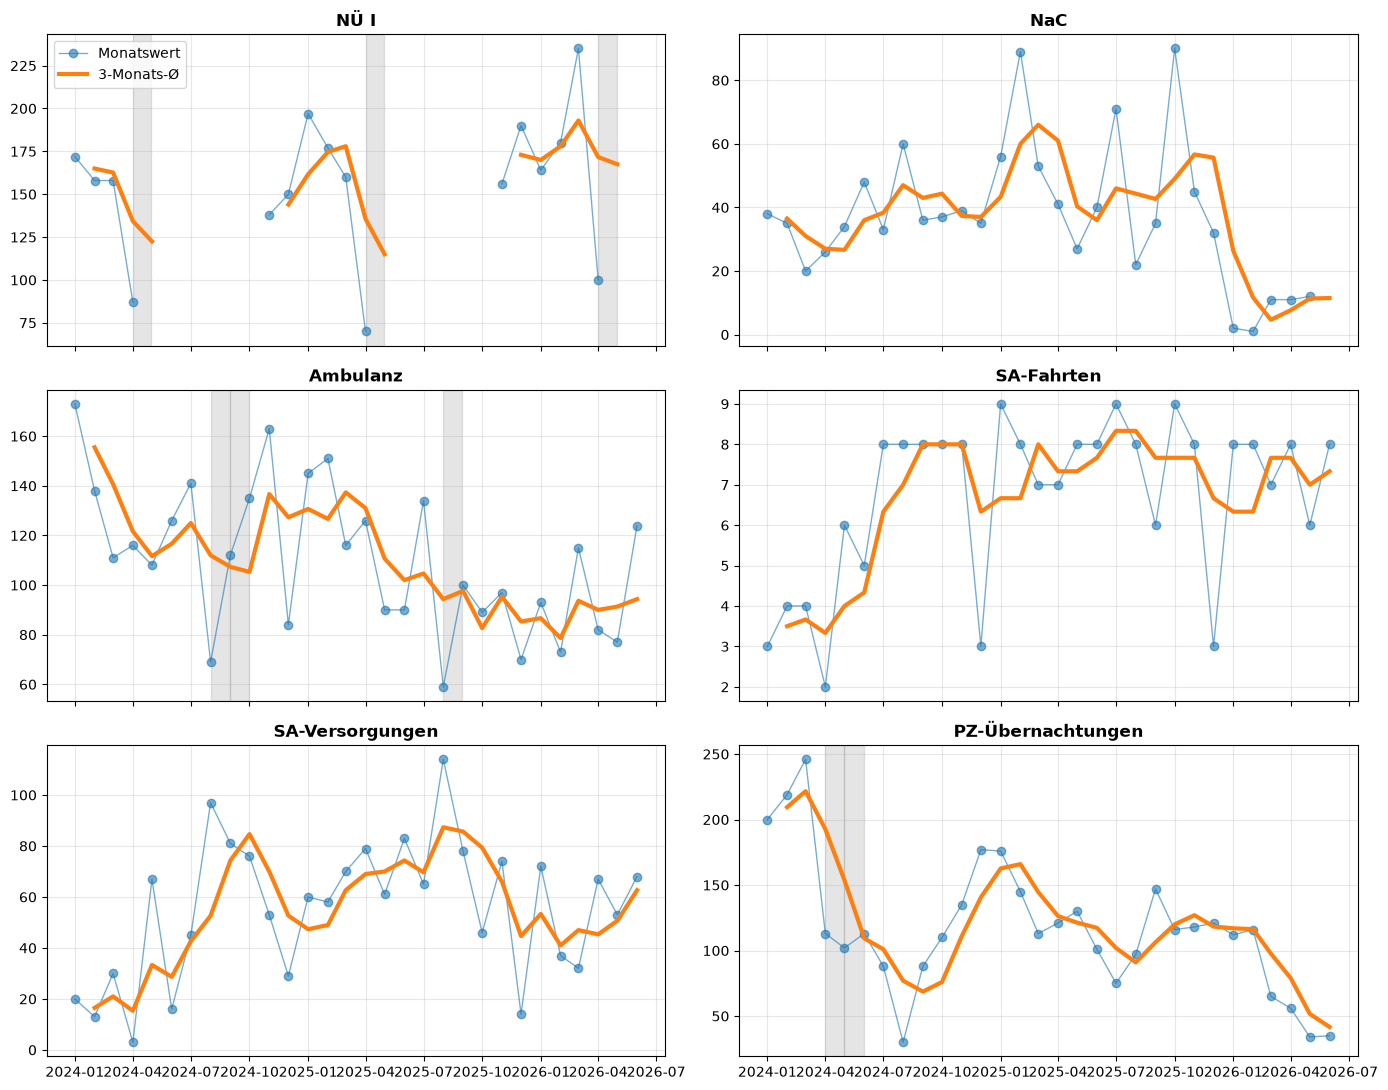

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for ax, s in zip(axes.flat, SPALTEN):
    ax.plot(df.index, df[s], marker="o", lw=1, alpha=.6, label="Monatswert")
    ax.plot(df.index, df[s].rolling(3, min_periods=2).mean(), lw=3, label="3-Monats-Ø")
    for (sp, j, m) in SCHLIESSTAGE:
        if sp == s:
            ax.axvspan(pd.Timestamp(j, m, 1), pd.Timestamp(j, m, 1) + pd.offsets.MonthEnd(0), color="grey", alpha=.2)
    ax.set_title(s, fontweight="bold")
axes[0, 0].legend()
plt.tight_layout(); plt.show()

## 5. Saisonalität – Jahre übereinandergelegt

So sieht man, ob z. B. der Sommer immer schwächer ist, oder ob ein Jahr generell höher/niedriger liegt.

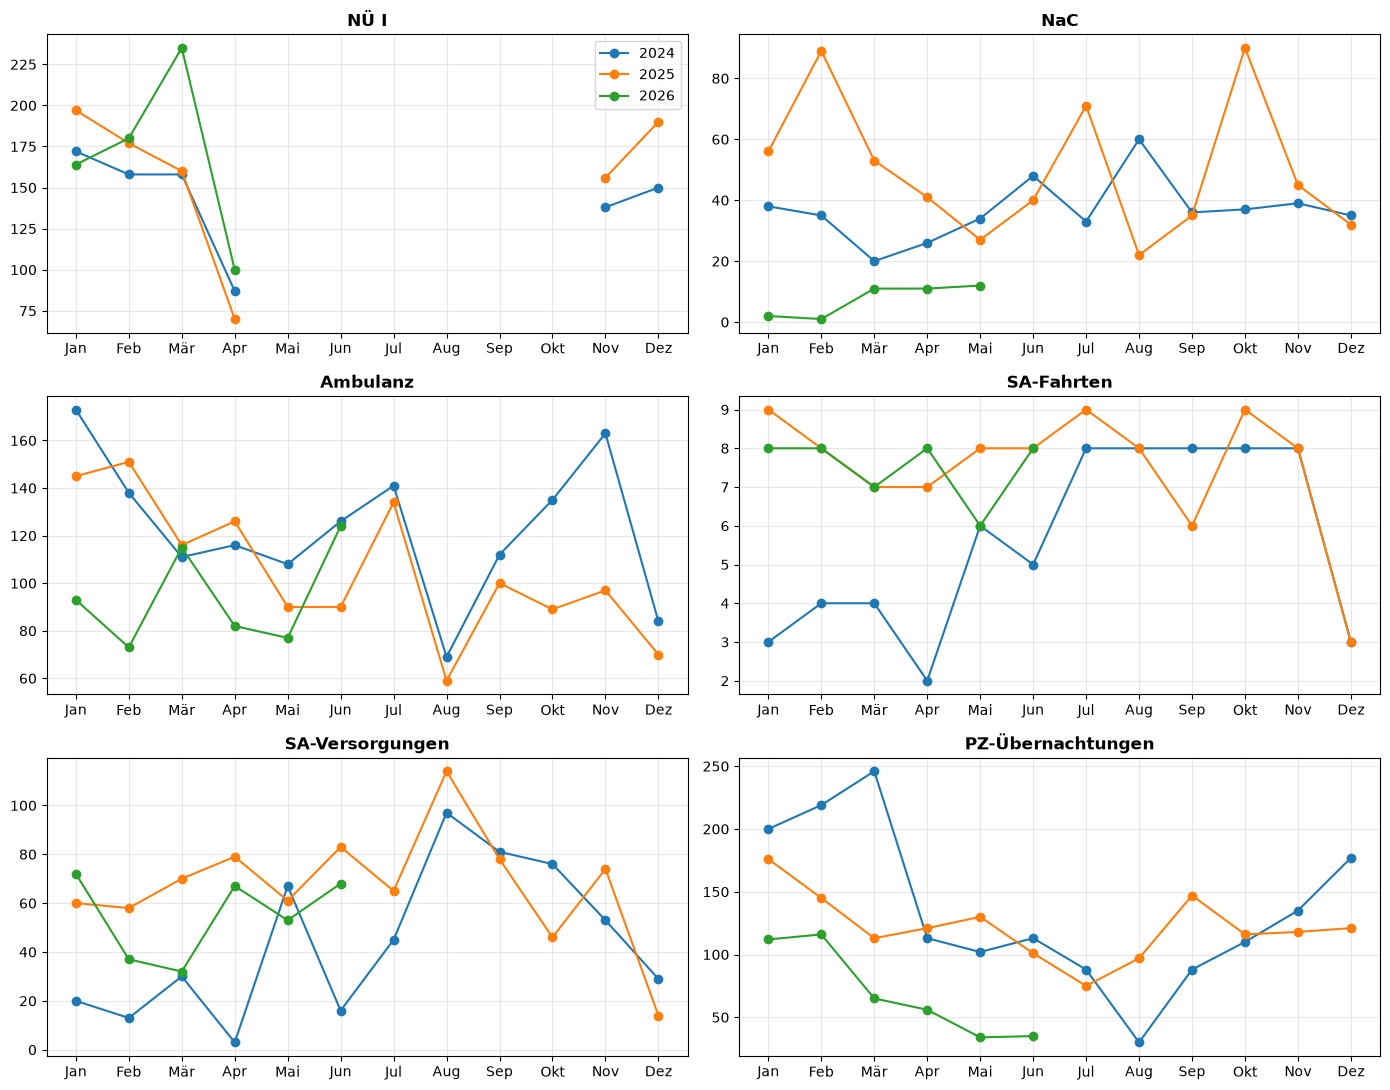

,NÜ I,NaC,Ambulanz,SA-Fahrten,SA-Versorgungen,PZ-Übernachtungen
MonatNr,,,,,,
Januar,178.0,32.0,137.0,7.0,51.0,163.0
Februar,172.0,42.0,121.0,7.0,36.0,160.0
März,184.0,28.0,114.0,6.0,44.0,141.0
April,86.0,26.0,108.0,6.0,50.0,97.0
Mai,NaN,24.0,92.0,7.0,60.0,89.0
Juni,NaN,44.0,113.0,7.0,56.0,83.0
Juli,NaN,52.0,138.0,8.0,55.0,82.0
August,NaN,41.0,64.0,8.0,106.0,64.0
September,NaN,36.0,106.0,7.0,80.0,118.0


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for ax, s in zip(axes.flat, SPALTEN):
    for j, g in df.groupby("Jahr"):
        ax.plot(g["MonatNr"], g[s], marker="o", label=str(j))
    ax.set_xticks(range(1, 13)); ax.set_xticklabels([m[:3] for m in MONATE])
    ax.set_title(s, fontweight="bold")
axes[0, 0].legend()
plt.tight_layout(); plt.show()

# Durchschnitt je Kalendermonat (alle Jahre) -> stärkste/schwächste Monate
saison_mittel = df.groupby("MonatNr")[SPALTEN].mean().rename(index=dict(enumerate(MONATE, 1)))
display(saison_mittel.round(0))

## 6. Statistischer Trendtest

Pro Bereich (bereinigt pro Öffnungstag):
- **Lineare Regression**: Steigung = durchschnittliche Veränderung pro Monat; umgerechnet in % pro Jahr bezogen auf den Mittelwert.
- **Mann-Kendall-Test** (über Kendalls τ gegen die Zeit): robuster, nicht-parametrischer Trendtest, unempfindlich gegen Ausreißer.
- **p < 0,05** gilt als statistisch signifikant. Bei nur ~30 Monaten und starker Saisonalität bitte vorsichtig interpretieren.

NÜ I wird hier ausgelassen (nur Wintermonate, zu wenige Werte) – siehe Abschnitt 2.

In [7]:
zeilen = []
for s in [c for c in SPALTEN if c != "NÜ I"]:
    y = pro_tag[s].dropna()
    x = (y.index.year - y.index[0].year) * 12 + (y.index.month - y.index[0].month)
    lr = stats.linregress(x, y.values)
    tau, p_mk = stats.kendalltau(x, y.values)
    pro_jahr = lr.slope * 12 / y.mean() * 100
    zeilen.append({"Bereich": s, "n Monate": len(y),
                   "Steigung/Monat (pro Tag)": lr.slope, "Trend % pro Jahr": pro_jahr,
                   "R²": lr.rvalue**2, "p Regression": lr.pvalue,
                   "Kendall τ": tau, "p Mann-Kendall": p_mk,
                   "Ergebnis": ("↑ steigend" if tau > 0 else "↓ fallend") if p_mk < .05 else "kein sign. Trend"})
trend = pd.DataFrame(zeilen).set_index("Bereich")
trend.round(3)

,n Monate,Steigung/Monat (pro Tag),Trend % pro Jahr,R²,p Regression,Kendall τ,p Mann-Kendall,Ergebnis
Bereich,,,,,,,,
NaC,29,-0.021,-20.351,0.058,0.206,-0.172,0.197,kein sign. Trend
Ambulanz,30,-0.062,-20.048,0.352,0.001,-0.417,0.001,↓ fallend
SA-Fahrten,30,0.003,18.467,0.195,0.015,0.299,0.025,↑ steigend
SA-Versorgungen,30,0.031,20.388,0.096,0.096,0.186,0.155,kein sign. Trend
PZ-Übernachtungen,30,-0.121,-36.537,0.371,0.000,-0.416,0.001,↓ fallend


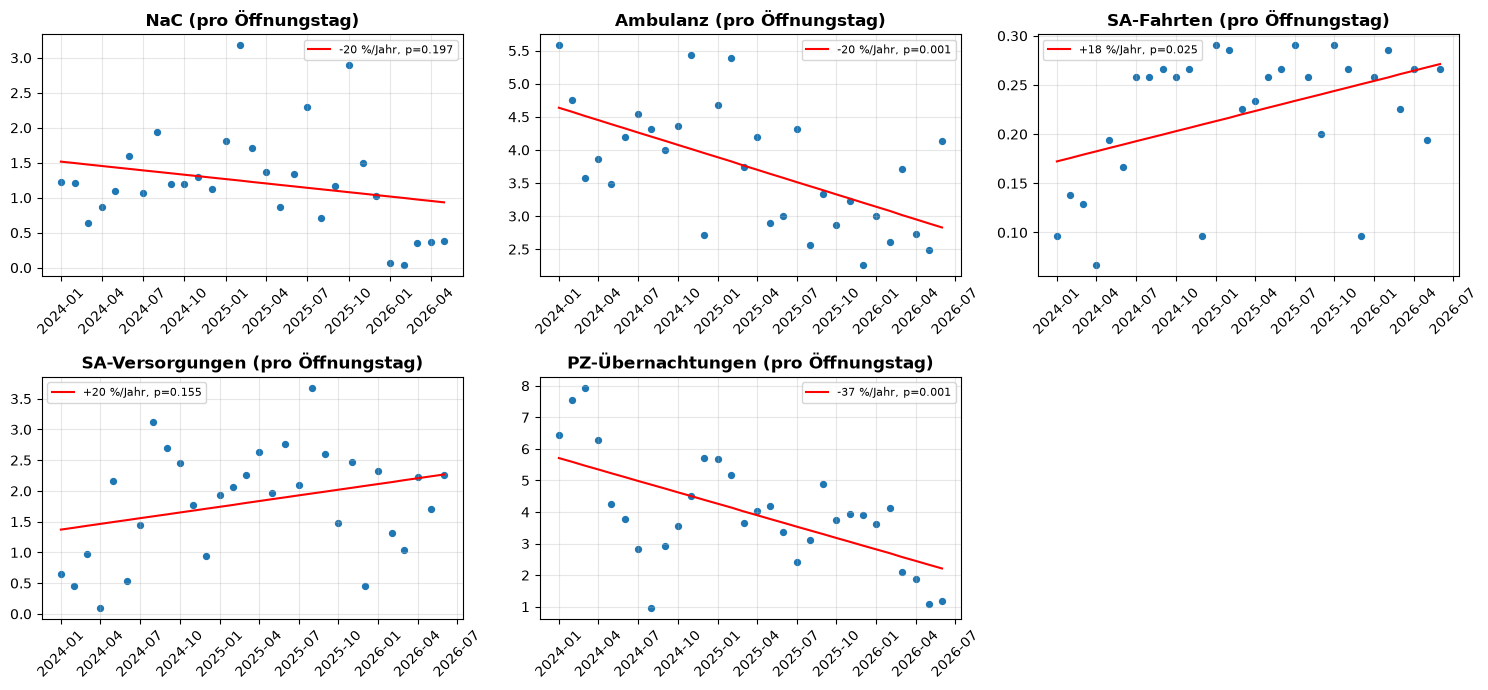

In [8]:
# Visualisierung: Trendlinien
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, s in zip(axes.flat, [c for c in SPALTEN if c != "NÜ I"]):
    y = pro_tag[s].dropna()
    x = (y.index.year - y.index[0].year) * 12 + (y.index.month - y.index[0].month)
    lr = stats.linregress(x, y.values)
    ax.scatter(y.index, y.values, s=18)
    ax.plot(y.index, lr.intercept + lr.slope * x, color="red",
            label=f"{trend.loc[s, 'Trend % pro Jahr']:+.0f} %/Jahr, p={trend.loc[s, 'p Mann-Kendall']:.3f}")
    ax.set_title(f"{s} (pro Öffnungstag)", fontweight="bold"); ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=45)
axes.flat[-1].axis("off")
plt.tight_layout(); plt.show()

## 7. Unterscheiden sich die Jahre signifikant? (Kruskal-Wallis)

Testet, ob die Monatswerte der Jahre aus derselben Verteilung stammen können
(nicht-parametrisch, geeignet für kleine Stichproben). Für einen fairen Vergleich nur **Januar–Juni**.

In [9]:
zeilen = []
for s in SPALTEN:
    gruppen = [pro_tag[(df["Jahr"] == j) & (df["MonatNr"] <= 6)][s].dropna() for j in (2024, 2025, 2026)]
    gruppen = [g for g in gruppen if len(g) >= 2]
    if len(gruppen) < 2:
        continue
    h, p = stats.kruskal(*gruppen)
    zeilen.append({"Bereich": s,
                   **{f"Median {j}": pro_tag[(df['Jahr'] == j) & (df['MonatNr'] <= 6)][s].median() for j in (2024, 2025, 2026)},
                   "p-Wert": p, "signifikant?": "ja" if p < .05 else "nein"})
pd.DataFrame(zeilen).set_index("Bereich").round(3)

,Median 2024,Median 2025,Median 2026,p-Wert,signifikant?
Bereich,,,,,
NÜ I,5.498,5.741,6.548,0.174,nein
NaC,1.152,1.538,0.355,0.003,ja
Ambulanz,4.033,3.971,2.867,0.064,nein
SA-Fahrten,0.133,0.262,0.262,0.003,ja
SA-Versorgungen,0.589,2.165,1.972,0.014,ja
PZ-Übernachtungen,6.365,4.113,1.982,0.005,ja


## 8. Kennzahlen: Versorgungen pro Fahrt (Straßenambulanz)

Mehr Fahrten heißt nicht automatisch mehr Versorgungen. **Versorgungen pro Fahrt** zeigt, wie „ausgelastet“ eine Fahrt ist.

,SA-Fahrten,SA-Versorgungen,Versorgungen pro Fahrt
Jahr,,,
2024,67.0,530.0,7.91
2025,90.0,802.0,8.91
2026,45.0,329.0,7.31


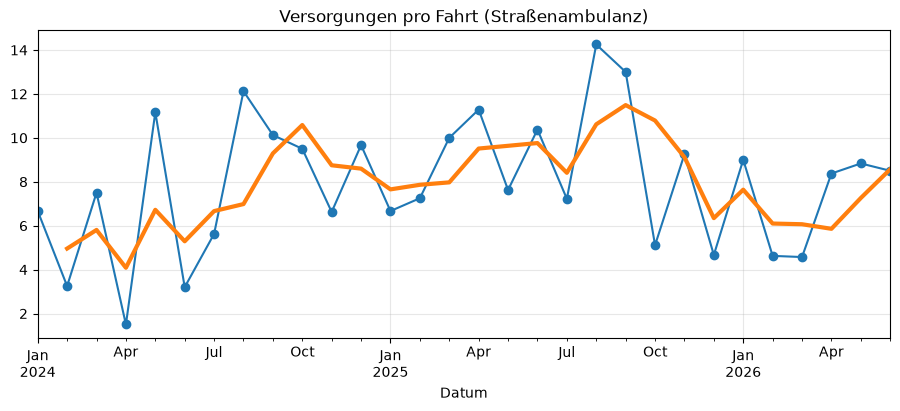

In [10]:
kpi = df[["Jahr", "SA-Fahrten", "SA-Versorgungen"]].copy()
kpi["Versorgungen pro Fahrt"] = kpi["SA-Versorgungen"] / kpi["SA-Fahrten"]
display(kpi.groupby("Jahr")[["SA-Fahrten", "SA-Versorgungen"]].sum()
          .assign(**{"Versorgungen pro Fahrt": lambda t: t["SA-Versorgungen"] / t["SA-Fahrten"]}).round(2))

ax = kpi["Versorgungen pro Fahrt"].plot(marker="o", title="Versorgungen pro Fahrt (Straßenambulanz)")
kpi["Versorgungen pro Fahrt"].rolling(3, min_periods=2).mean().plot(ax=ax, lw=3)
plt.show()

## 9. Zusammenhänge zwischen den Bereichen (Spearman-Korrelation)

Gehen z. B. hohe Ambulanz-Zahlen mit hohen Pflegezimmer-Übernachtungen einher?
Werte nahe +1 = gleichläufig, nahe −1 = gegenläufig, nahe 0 = kein Zusammenhang.
**Achtung:** Korrelation ≠ Kausalität – beide können z. B. einfach vom Winter abhängen.

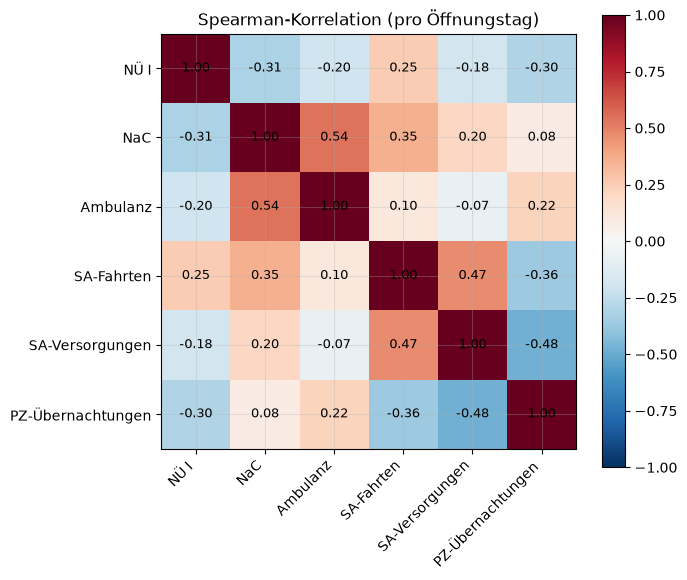

In [11]:
korr = pro_tag.corr(method="spearman", min_periods=8)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(korr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(korr))); ax.set_xticklabels(korr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(korr))); ax.set_yticklabels(korr.columns)
for i in range(len(korr)):
    for j in range(len(korr)):
        if pd.notna(korr.iat[i, j]):
            ax.text(j, i, f"{korr.iat[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im); plt.title("Spearman-Korrelation (pro Öffnungstag)"); plt.tight_layout(); plt.show()

## 10. Auffällige Monate (Ausreißer)

Markiert Monate, die stark vom typischen Niveau abweichen (robuster z-Wert über Median & MAD, |z| > 2,5).

In [12]:
auff = []
for s in SPALTEN:
    y = pro_tag[s].dropna()
    mad = stats.median_abs_deviation(y, scale="normal")
    if mad == 0:
        continue
    z = (y - y.median()) / mad
    for d, v in z[abs(z) > 2.5].items():
        auff.append({"Monat": d.strftime("%Y-%m"), "Bereich": s, "Wert": df.loc[d, s],
                     "robuster z": round(v, 1), "Richtung": "ungewöhnlich hoch" if v > 0 else "ungewöhnlich niedrig",
                     "Bemerkung": df.loc[d, "Bemerkung"] if pd.notna(df.loc[d, "Bemerkung"]) else ""})
pd.DataFrame(auff) if auff else print("Keine auffälligen Monate.")

,Monat,Bereich,Wert,robuster z,Richtung,Bemerkung
0,2025-02,NaC,89.0,4.1,ungewöhnlich hoch,
1,2025-10,NaC,90.0,3.5,ungewöhnlich hoch,
2,2024-01,SA-Fahrten,3.0,-3.6,ungewöhnlich niedrig,
3,2024-02,SA-Fahrten,4.0,-2.7,ungewöhnlich niedrig,
4,2024-03,SA-Fahrten,4.0,-2.9,ungewöhnlich niedrig,
5,2024-04,SA-Fahrten,2.0,-4.3,ungewöhnlich niedrig,NÜ I nur bis 15.04.2024(?); Pflegezimmer Schli...
6,2024-12,SA-Fahrten,3.0,-3.6,ungewöhnlich niedrig,
7,2025-12,SA-Fahrten,3.0,-3.6,ungewöhnlich niedrig,
8,2024-02,PZ-Übernachtungen,219.0,2.6,ungewöhnlich hoch,
9,2024-03,PZ-Übernachtungen,246.0,2.9,ungewöhnlich hoch,


## 11. Hochrechnung 2026 (grobe Schätzung)

Annahme: Der Anteil von Januar–Juni am Gesamtjahr ist 2026 so wie im Durchschnitt 2024/2025.
Das ist eine **einfache Schätzung**, keine Prognose mit Sicherheitsgarantie.

In [13]:
anteil = pd.concat([summe(j, H1) / summe(j, range(1, 13)) for j in (2024, 2025)], axis=1).mean(axis=1)
hoch = pd.DataFrame({
    "2024": summe(2024, range(1, 13)), "2025": summe(2025, range(1, 13)),
    "Jan–Jun 2026 (Ist)": summe(2026, H1),
    "Anteil Jan–Jun (Ø 24/25)": anteil,
})
hoch["Hochrechnung 2026"] = hoch["Jan–Jun 2026 (Ist)"] / hoch["Anteil Jan–Jun (Ø 24/25)"]
hoch["Δ ggü. 2025 %"] = (hoch["Hochrechnung 2026"] / hoch["2025"] - 1) * 100
print("NÜ I: nur Wintermonate -> Hochrechnung wenig aussagekräftig. NaC: Juni 2026 fehlt.")
hoch.round(2)

NÜ I: nur Wintermonate -> Hochrechnung wenig aussagekräftig. NaC: Juni 2026 fehlt.


,2024,2025,Jan–Jun 2026 (Ist),Anteil Jan–Jun (Ø 24/25),Hochrechnung 2026,Δ ggü. 2025 %
NÜ I,863.0,950.0,679.0,0.65,1042.95,9.78
NaC,441.0,601.0,37.0,0.48,76.69,-87.24
Ambulanz,1476.0,1267.0,564.0,0.54,1035.12,-18.30
SA-Fahrten,67.0,90.0,45.0,0.44,102.22,13.58
SA-Versorgungen,530.0,802.0,329.0,0.40,829.13,3.38
PZ-Übernachtungen,1621.0,1460.0,418.0,0.58,726.36,-50.25


## 12. Zusammenfassung (automatisch)

In [14]:
for s in SPALTEN:
    h1 = vergleich_h1.loc[s]
    txt = f"• {s}: Jan–Jun 2025 → 2026: {h1['Jan–Jun 2025']:.0f} → {h1['Jan–Jun 2026']:.0f} ({h1['Δ 25→26 %']:+.0f} %)"
    if s in trend.index:
        txt += f" | Langzeittrend: {trend.loc[s, 'Ergebnis']} ({trend.loc[s, 'Trend % pro Jahr']:+.0f} %/Jahr, p={trend.loc[s, 'p Mann-Kendall']:.3f})"
    print(txt)

• NÜ I: Jan–Jun 2025 → 2026: 604 → 679 (+12 %)
• NaC: Jan–Jun 2025 → 2026: 306 → 37 (-88 %) | Langzeittrend: kein sign. Trend (-20 %/Jahr, p=0.197)
• Ambulanz: Jan–Jun 2025 → 2026: 718 → 564 (-21 %) | Langzeittrend: ↓ fallend (-20 %/Jahr, p=0.001)
• SA-Fahrten: Jan–Jun 2025 → 2026: 47 → 45 (-4 %) | Langzeittrend: ↑ steigend (+18 %/Jahr, p=0.025)
• SA-Versorgungen: Jan–Jun 2025 → 2026: 411 → 329 (-20 %) | Langzeittrend: kein sign. Trend (+20 %/Jahr, p=0.155)
• PZ-Übernachtungen: Jan–Jun 2025 → 2026: 786 → 418 (-47 %) | Langzeittrend: ↓ fallend (-37 %/Jahr, p=0.001)
